# Rule Text Analysis

In [13]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [14]:
results_dir = Path('.')

def clean_rule_text(text):
    text = re.sub(r'R\d+:\s*', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def count_words(text):
    return len(re.findall(r'\b\w+\b', text))

def load_rule_rows():
    rows = []
    for path in sorted(results_dir.glob('*_rulebased_*_llm_results.jsonl')):
        with open(path, 'r') as f:
            for line in f:
                run = json.loads(line)
                for class_name, rule_text in run.get('extracted_rules', {}).items():
                    rule_text = clean_rule_text(rule_text)
                    if not rule_text:
                        continue

                    rows.append({
                        'dataset': run['dataset'],
                        'k': run['k'],
                        'num_rules_setting': run['num_rules'],
                        'accuracy': run['accuracy'],
                        'repetition': run.get('repetition'),
                        'class_name': class_name,
                        'rule_text': rule_text,
                        'num_words': count_words(rule_text),
                        'num_chars': len(rule_text),
                    })
    return pd.DataFrame(rows)

def load_run_rows():
    rows = []
    for path in sorted(results_dir.glob('*_rulebased_*_llm_results.jsonl')):
        with open(path, 'r') as f:
            for line in f:
                run = json.loads(line)
                rule_texts = [clean_rule_text(text) for text in run.get('extracted_rules', {}).values()]
                rule_texts = [text for text in rule_texts if text]
                if not rule_texts:
                    continue

                rows.append({
                    'dataset': run['dataset'],
                    'k': run['k'],
                    'num_rules_setting': run['num_rules'],
                    'accuracy': run['accuracy'],
                    'repetition': run.get('repetition'),
                    'num_class_rules': len(rule_texts),
                    'total_num_words': sum(count_words(text) for text in rule_texts),
                    'total_num_chars': sum(len(text) for text in rule_texts),
                })
    return pd.DataFrame(rows)

def plot_scatter(df, metric, title, xlabel):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(df[metric], df['accuracy'], alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.2)
    plt.show()

def plot_scatter_per_dataset(df, metric, xlabel):
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), squeeze=False)
    for ax, dataset in zip(axes[0], datasets):
        subset = df[df['dataset'] == dataset]
        ax.scatter(subset[metric], subset['accuracy'], alpha=0.7)
        ax.set_title(dataset)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

def fit_line(df, metric):
    if len(df) < 2 or df[metric].nunique() < 2:
        return np.nan, np.nan, np.nan
    x = df[metric].to_numpy()
    y = df['accuracy'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    corr = np.corrcoef(x, y)[0, 1]
    return slope, intercept, corr

def plot_trend(df, metric, title, xlabel):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(df[metric], df['accuracy'], alpha=0.7)
    slope, intercept, corr = fit_line(df, metric)
    if pd.notna(slope):
        x = np.linspace(df[metric].min(), df[metric].max(), 100)
        ax.plot(x, slope * x + intercept, color='black')
        ax.set_title(f'{title} (corr={corr:.3f})')
    else:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.2)
    plt.show()

def plot_trend_per_dataset(df, metric, xlabel):
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), squeeze=False)
    for ax, dataset in zip(axes[0], datasets):
        subset = df[df['dataset'] == dataset]
        ax.scatter(subset[metric], subset['accuracy'], alpha=0.7)
        slope, intercept, corr = fit_line(subset, metric)
        if pd.notna(slope):
            x = np.linspace(subset[metric].min(), subset[metric].max(), 100)
            ax.plot(x, slope * x + intercept, color='black')
            ax.set_title(f'{dataset} (corr={corr:.3f})')
        else:
            ax.set_title(dataset)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

def correlation_table(df, metric):
    rows = []
    for dataset, subset in df.groupby('dataset'):
        slope, intercept, corr = fit_line(subset, metric)
        rows.append({'dataset': dataset, 'slope': slope, 'corr': corr, 'count': len(subset)})
    return pd.DataFrame(rows).round(3)


In [15]:
rules_df = load_rule_rows()
runs_df = load_run_rows()
print(rules_df.shape)
display(rules_df.head())
print(runs_df.shape)
display(runs_df.head())


(126, 9)


,dataset,k,num_rules_setting,accuracy,repetition,class_name,rule_text,num_words,num_chars
0,Chinatown,2,2,0.85,1,class_0,The series starts at a clearly positive level ...,53,299
1,Chinatown,2,2,0.85,1,class_1,The series starts very close to zero and remai...,56,297
2,Chinatown,2,2,0.90,2,class_0,In the very early part of the series (time ste...,55,285
3,Chinatown,2,2,0.90,2,class_1,In the very early part of the series (time ste...,61,331
4,Chinatown,2,2,0.94,3,class_0,The value at time 0 is at least 0.15 higher th...,60,286


(57, 8)


,dataset,k,num_rules_setting,accuracy,repetition,num_class_rules,total_num_words,total_num_chars
0,Chinatown,2,2,0.85,1,2,109,596
1,Chinatown,2,2,0.90,2,2,116,616
2,Chinatown,2,2,0.94,3,2,111,544
3,Chinatown,3,12,0.97,1,2,96,521
4,Chinatown,3,12,0.96,2,2,97,500


In [16]:
rules_df = rules_df[rules_df['k'] == 3]
runs_df = runs_df[runs_df['k'] == 3]


In [17]:
runs_df.groupby(['dataset', 'num_rules_setting'])['accuracy'].agg(['count', 'mean']).round(3)


count   mean
dataset               num_rules_setting              
Chinatown             1                      2  0.925
                      2                      2  0.820
                      3                      2  0.955
                      12                     3  0.960
ECG200                1                      3  0.457
                      2                      3  0.640
                      3                      3  0.680
                      12                     3  0.707
SonyAIBORobotSurface1 1                      3  0.550
                      2                      3  0.573
                      3                      3  0.573
                      12                     3  0.643
UMD                   1                      3  0.953
                      2                      3  0.910
                      3                      3  0.923
                      12                     3  0.863

## Word Analysis

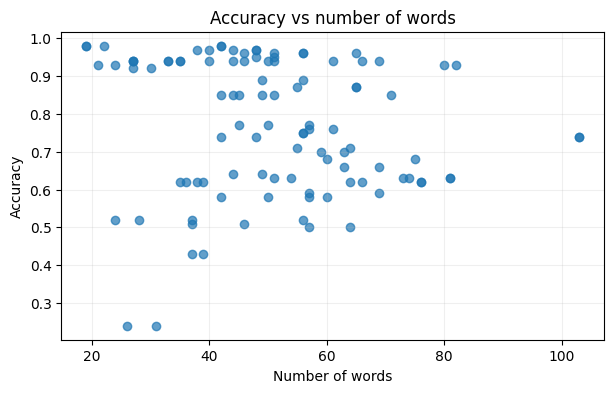

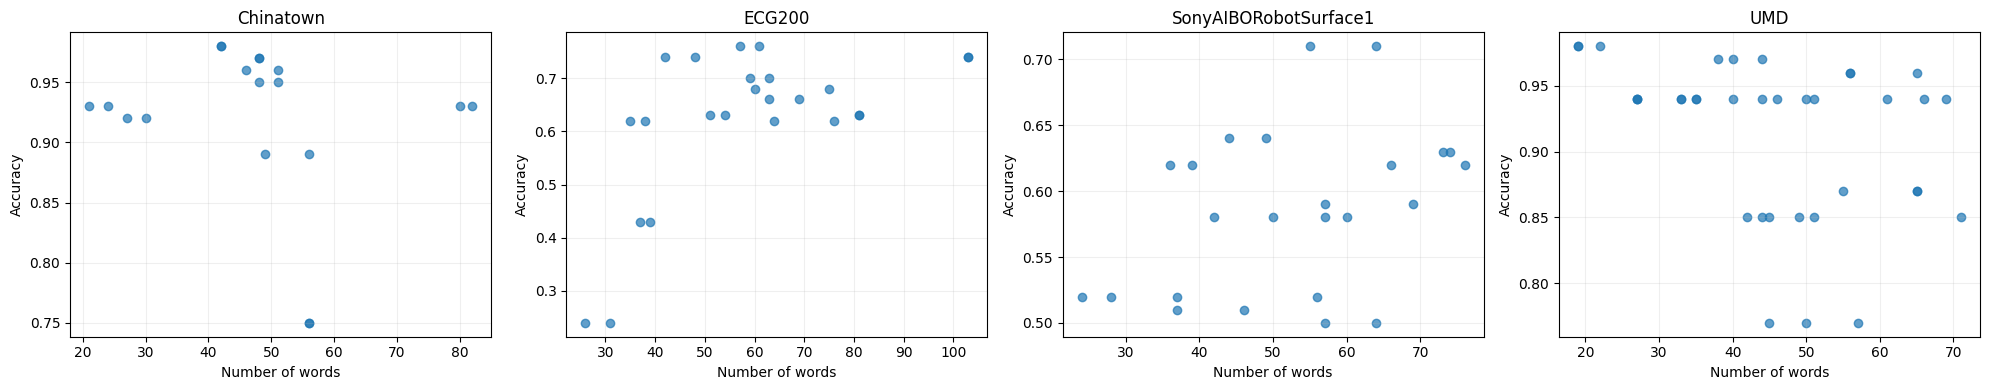

In [18]:
plot_scatter(rules_df, 'num_words', 'Accuracy vs number of words', 'Number of words')
plot_scatter_per_dataset(rules_df, 'num_words', 'Number of words')


Pearson Correlation Coefficient

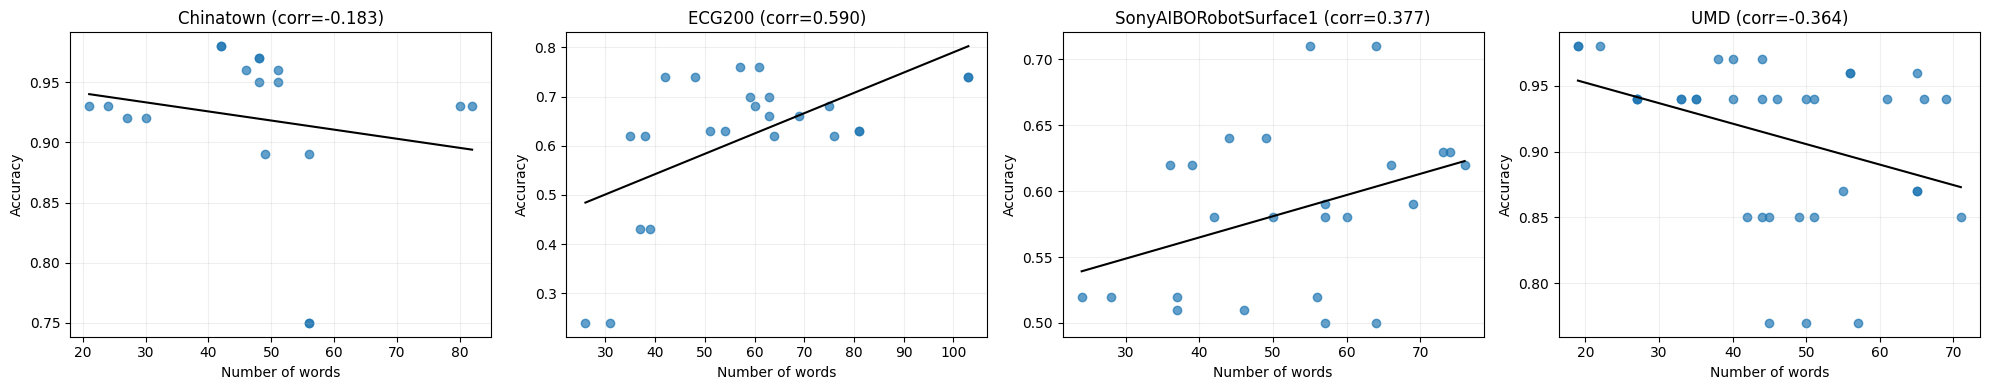

,dataset,slope,corr,count
0,Chinatown,-0.001,-0.183,18
1,ECG200,0.004,0.590,24
2,SonyAIBORobotSurface1,0.002,0.377,24
3,UMD,-0.002,-0.364,36


In [19]:
plot_trend_per_dataset(rules_df, 'num_words', 'Number of words')
display(correlation_table(rules_df, 'num_words'))


## Aggregated Word Analysis


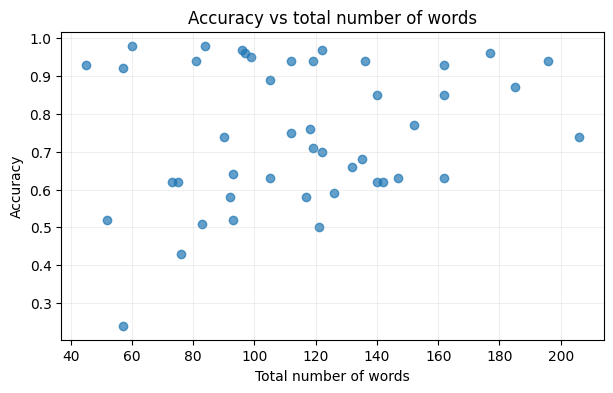

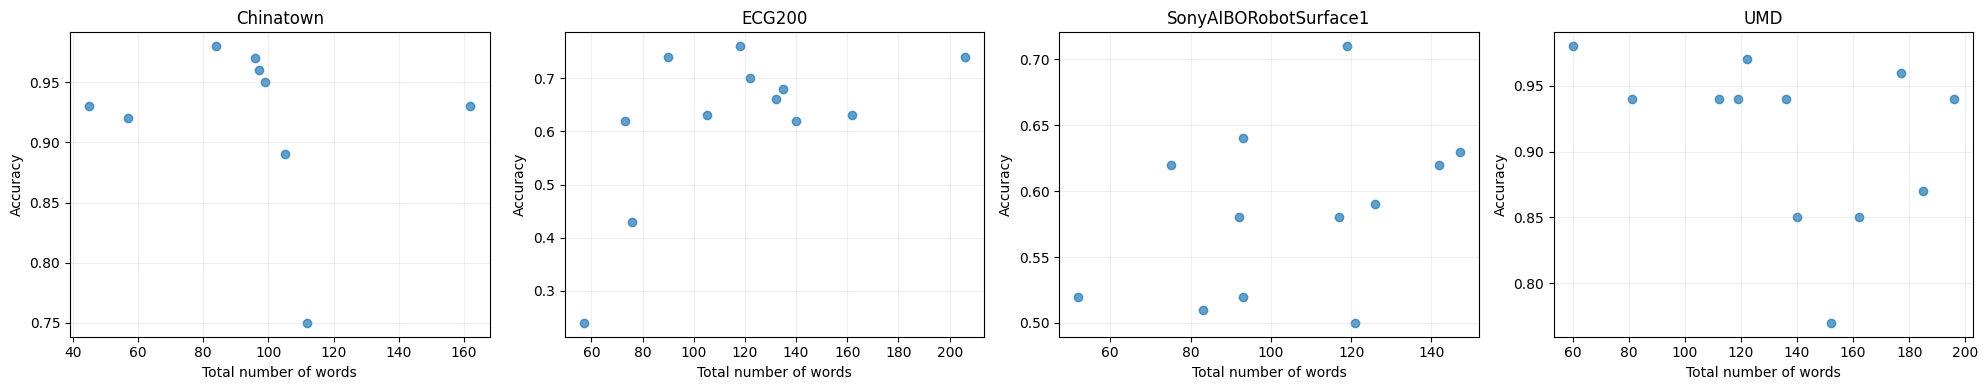

In [20]:
plot_scatter(runs_df, 'total_num_words', 'Accuracy vs total number of words', 'Total number of words')
plot_scatter_per_dataset(runs_df, 'total_num_words', 'Total number of words')


Pearson correlation coefficient


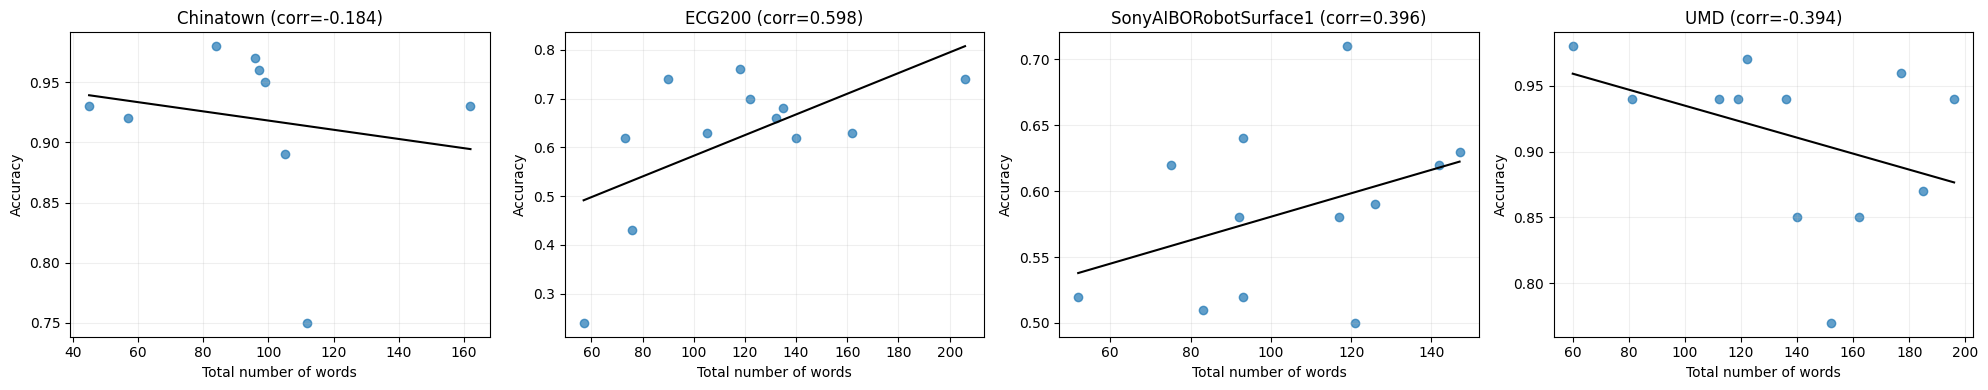

,dataset,slope,corr,count
0,Chinatown,-0.000,-0.184,9
1,ECG200,0.002,0.598,12
2,SonyAIBORobotSurface1,0.001,0.396,12
3,UMD,-0.001,-0.394,12


In [21]:
plot_trend_per_dataset(runs_df, 'total_num_words', 'Total number of words')
display(correlation_table(runs_df, 'total_num_words'))


## Character Analysis

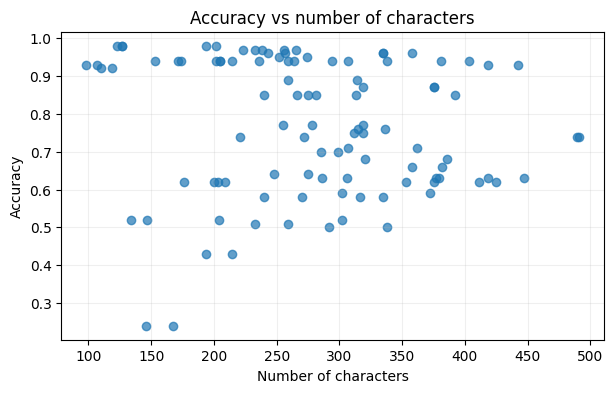

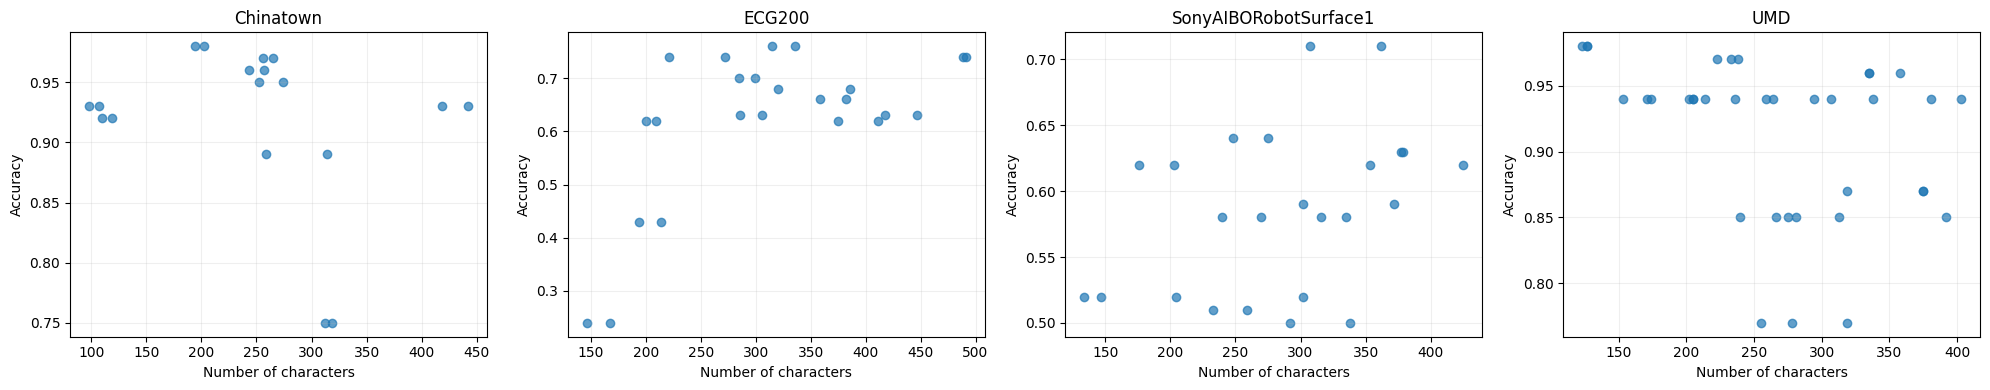

In [22]:
plot_scatter(rules_df, 'num_chars', 'Accuracy vs number of characters', 'Number of characters')
plot_scatter_per_dataset(rules_df, 'num_chars', 'Number of characters')


Pearson correlation coefficient

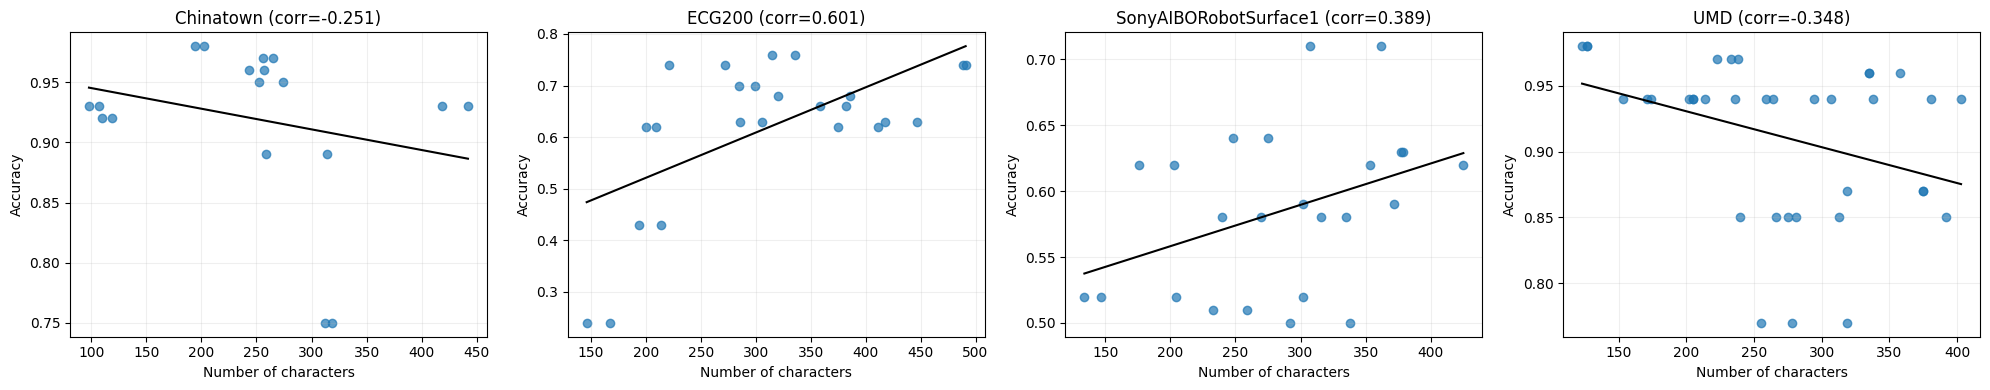

,dataset,slope,corr,count
0,Chinatown,-0.000,-0.251,18
1,ECG200,0.001,0.601,24
2,SonyAIBORobotSurface1,0.000,0.389,24
3,UMD,-0.000,-0.348,36


In [23]:
plot_trend_per_dataset(rules_df, 'num_chars', 'Number of characters')
display(correlation_table(rules_df, 'num_chars'))


## Subset new prompt (rules==12)

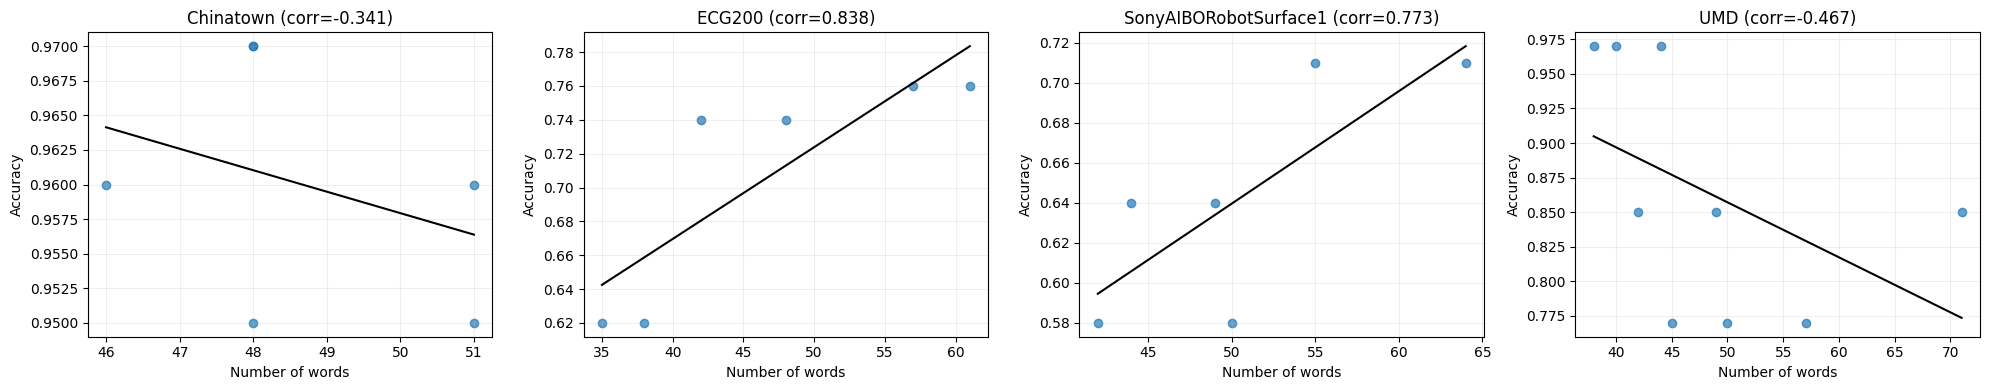

In [24]:
subset = rules_df[rules_df['num_rules_setting'] == 12]
plot_trend_per_dataset(subset, 'num_words', 'Number of words')

In [31]:
chinatown_12 = rules_df[(rules_df['dataset'] == 'Chinatown') & (rules_df['num_rules_setting'] == 12)]
pivot = chinatown_12.pivot_table(index='repetition', columns='class_name', values='num_words')
display(pivot)

class_name,class_0,class_1
repetition,,
1,48.0,48.0
2,51.0,46.0
3,51.0,48.0


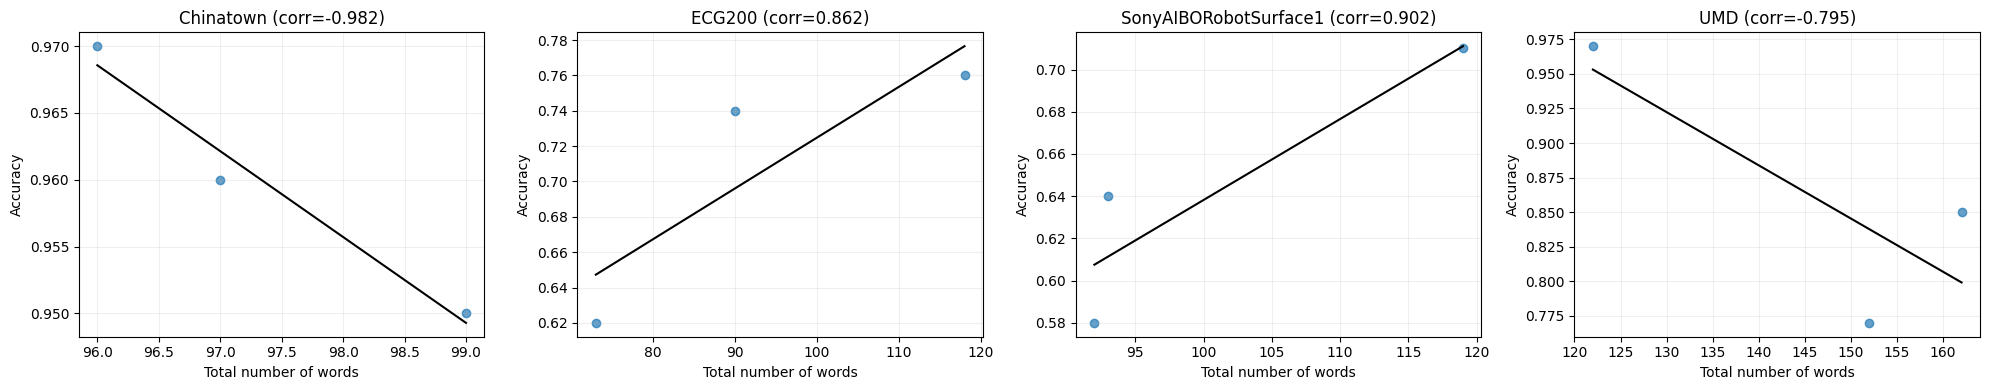

In [27]:
subset = runs_df[runs_df['num_rules_setting'] == 12]
plot_trend_per_dataset(subset, 'total_num_words', 'Total number of words')